In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install kaggle

In [3]:
kaggle = "/content/drive/MyDrive/Praktikum02/Praktikum13/data/kaggle.json"

In [4]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
  0% 0.00/66.7M [00:00<?, ?B/s]
100% 66.7M/66.7M [00:00<00:00, 1.38GB/s]


In [6]:
from zipfile import ZipFile
import os
file_name = '/content/handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [7]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [8]:
len(data_0)

2236

In [9]:
# IMPORT LIBRARY
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Preprocessing dengan Inversi & Normalisasi
import cv2
import numpy as np
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

X = []
y = []

for label in range(10):
    folder_path = f'/content/dataset/{label}'
    if not os.path.exists(folder_path): continue
    for img_name in os.listdir(folder_path):
        try:
            img = cv2.imread(os.path.join(folder_path, img_name), cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            # CEK INVERSI: MNIST standar adalah tulisan putih di latar hitam.
            # Jika rata-rata piksel > 127, berarti latar putih, maka kita balik (Invert).
            if np.mean(img) > 127:
                img = cv2.bitwise_not(img)

            X.append(img)
            y.append(label)
        except:
            continue

X = np.array(X)
y = np.array(y)

# Normalisasi 0-1
X = X.astype('float32') / 255.0

# Reshape untuk input MLP (Flatten manual)
X_flat = X.reshape(-1, 784)

# Split 80:20 (Stratify agar seimbang setiap angka)
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    # Hidden Layer 1
    Dense(512, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden Layer 2
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output Layer
    Dense(10, activation='softmax')
])

# Gunakan Learning Rate yang lebih kecil (0.0001) agar belajar lebih teliti
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# --- NORMALISASI (Kunci Akurasi Tinggi) ---
# Mengubah rentang 0-255 menjadi 0-1
X = X.astype('float32') / 255.0

In [13]:
# Reshape untuk MLP (Flat)
X_flat = X.reshape(-1, 28*28)

In [14]:
# Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_test_cat = tf.keras.utils.to_categorical(y_test, 10)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# Konfigurasi Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True, # Mengembalikan bobot terbaik ke model setelah selesai
    verbose=1
)

In [16]:
# Proses Training
print("Memulai proses training...")
history = model.fit(
    X_train, y_train_cat,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop],
    verbose=1
)

Memulai proses training...
Epoch 1/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3211 - loss: 1.9729 - val_accuracy: 0.4894 - val_loss: 1.9915
Epoch 2/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5270 - loss: 1.4703 - val_accuracy: 0.5883 - val_loss: 1.3190
Epoch 3/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5890 - loss: 1.2911 - val_accuracy: 0.6277 - val_loss: 1.1848
Epoch 4/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6397 - loss: 1.1504 - val_accuracy: 0.6769 - val_loss: 1.0486
Epoch 5/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6773 - loss: 1.0296 - val_accuracy: 0.7207 - val_loss: 0.9378
Epoch 6/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7129 - loss: 0.9394 - val_accuracy: 0.7448 - val_loss: 0.8513
Epoch 7/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7448 - loss: 0.8371 - val_accuracy: 0.7546 - val_loss: 0.8019
Epoch 8/100
539/539 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accura

In [17]:
# Evaluasi Akhir pada Data Test (Hasil Paten)
print("\n--- HASIL EVALUASI AKHIR (PATEN) ---")
y_pred = np.argmax(model.predict(X_test), axis=1)

# Menghitung akurasi final secara eksplisit
final_acc = accuracy_score(y_test, y_pred)

print(f"Final Test Accuracy: {final_acc:.4f}")


--- HASIL EVALUASI AKHIR (PATEN) ---
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Final Test Accuracy: 0.9054


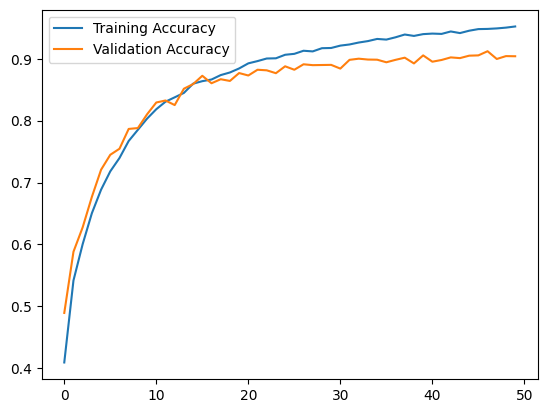

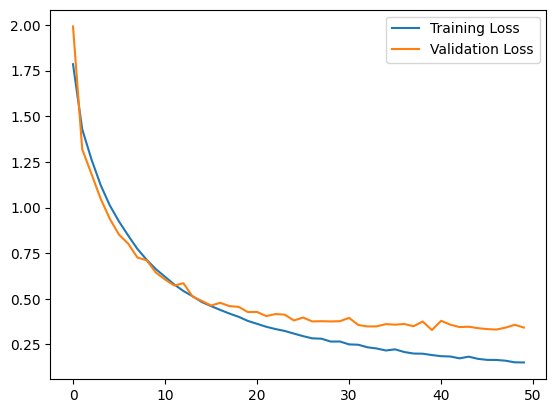

In [18]:
# VISUALISASI AKURASI & LOSS
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

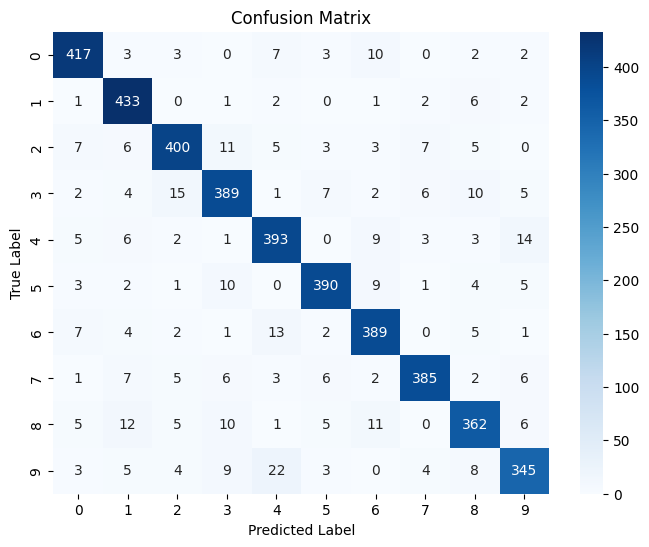

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       447
           1       0.90      0.97      0.93       448
           2       0.92      0.89      0.90       447
           3       0.89      0.88      0.89       441
           4       0.88      0.90      0.89       436
           5       0.93      0.92      0.92       425
           6       0.89      0.92      0.90       424
           7       0.94      0.91      0.93       423
           8       0.89      0.87      0.88       417
           9       0.89      0.86      0.87       403

    accuracy                           0.91      4311
   macro avg       0.91      0.90      0.90      4311
weighted avg       0.91      0.91      0.91      4311



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))
